In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [6]:
data = pd.read_csv(r"C:\Users\lenovo\Desktop\NSE_INFY.csv")
data.head()

,Date,Open,High,Low,Close,Volume
0,1996-01-01,0.484827,0.485899,0.482445,0.485899,204799.99980
1,1996-01-02,0.484827,0.487209,0.483934,0.483934,204799.99980
2,1996-01-03,0.487209,0.487209,0.487209,0.487209,102399.99990
3,1996-01-04,0.482445,0.484827,0.482445,0.483993,307199.99970
4,1996-01-05,0.478275,0.478275,0.478275,0.478275,51199.99995


In [7]:
# Convert Date column
data['Date'] = pd.to_datetime(data['Date'])

# Sort by date (VERY IMPORTANT for time series)
data = data.sort_values('Date')

# Reset index
data.reset_index(drop=True, inplace=True)

# Check null values
print(data.isnull().sum())

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


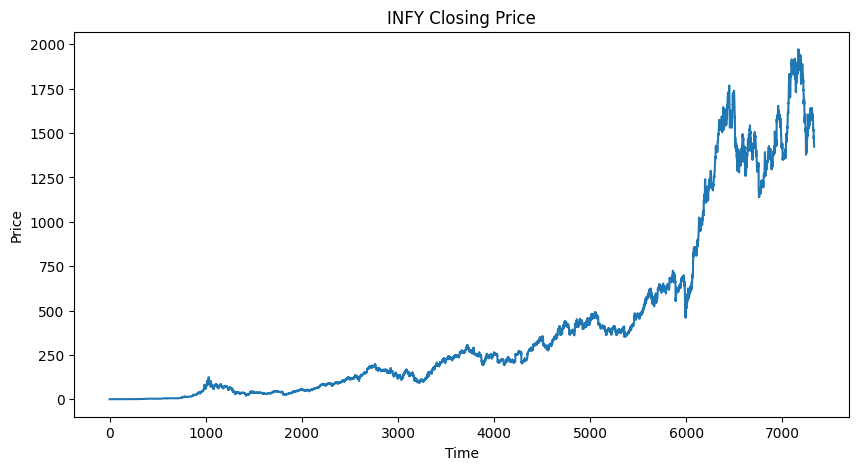

In [8]:
plt.figure(figsize=(10,5))
plt.plot(data['Close'])
plt.title("INFY Closing Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

## Feature Engineering

In [9]:
data['SMA_10'] = data['Close'].rolling(window=10).mean()
data['SMA_20'] = data['Close'].rolling(window=20).mean()

In [10]:
delta = data['Close'].diff()

gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()

rs = gain / loss
data['RSI'] = 100 - (100 / (1 + rs))

In [11]:
data['BB_Middle'] = data['Close'].rolling(window=20).mean()
data['BB_Upper'] = data['BB_Middle'] + 2*data['Close'].rolling(window=20).std()
data['BB_Lower'] = data['BB_Middle'] - 2*data['Close'].rolling(window=20).std()

In [12]:
data = data.dropna()

In [13]:
features = ['Close', 'SMA_10', 'SMA_20', 'RSI', 'BB_Upper', 'BB_Lower']

dataset = data[features]

In [38]:
scaled_data = dataset.values

## LSTM INPUT

In [39]:
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i][0])

X = np.array(X)
y = np.array(y)

In [17]:
print(type(X))
print(X.shape)

<class 'numpy.ndarray'>
(7252, 60, 6)


In [18]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [19]:
model.add(Input(shape=(X.shape[1], X.shape[2])))

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

model = Sequential()

model.add(Input(shape=(X.shape[1], X.shape[2])))

model.add(LSTM(32, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

In [21]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 32)              │           4,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,345 (52.13 KB)

 Trainable params: 13,345 (52.13 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 8.0570e-04 - val_loss: 0.0065
Epoch 2/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 3.1861e-04 - val_loss: 0.0067
Epoch 3/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 2.1478e-04 - val_loss: 0.0057
Epoch 4/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 1.8798e-04 - val_loss: 0.0058
Epoch 5/5
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 1.6742e-04 - val_loss: 0.0062


In [23]:
predictions = model.predict(X_test)

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


In [28]:
print(predictions.shape)

(1451,)


In [29]:
import numpy as np

temp = np.zeros((len(predictions), scaled_data.shape[1]))
temp[:,0] = predictions   # FIXED

predictions = scaler.inverse_transform(temp)[:,0]

In [43]:
predictions = model.predict(X_test).reshape(-1)
y_test_actual = y_test

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [36]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
mae = mean_absolute_error(y_test_actual, predictions)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 4483765082.768859
MAE: 4388693022.97041


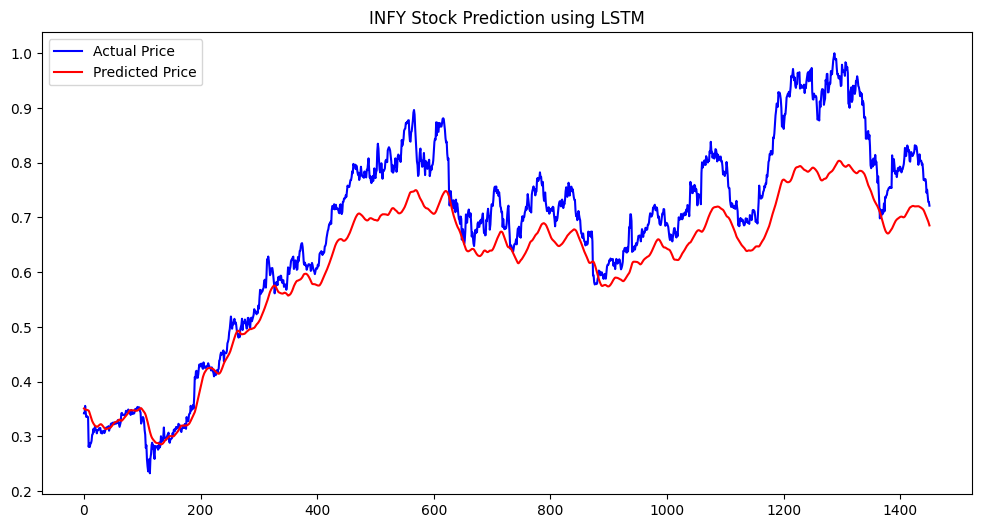

In [44]:
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual Price', color='blue')
plt.plot(predictions, label='Predicted Price', color='red')
plt.legend()
plt.title("INFY Stock Prediction using LSTM")
plt.show()